In [1]:
import asyncio
import logging

# This demo uses Academy to launch agents on Polaris
import academy
from academy.manager import Manager
from academy.agent import Agent, action
from academy.handle import Handle
from academy.exchange.cloud import HttpExchangeFactory
from academy.logging import init_logging

# We use Globus Compute to launch Academy Agents on Polaris
from globus_compute_sdk import Executor as GlobusComputeExecutor

print(academy.__version__)

0.4.0


In [2]:
# Get tokens for the Argonne Inference Endpoint. This step will emit a Globus Auth URL that 
# will take you to an authentication page. 
# NOTE: You need to auth an ALCF/UChicago account to use the Argonne Inference Endpoint

from inference_auth_token import get_access_token
api_key = get_access_token()

In [3]:
# Please note that this is a work in **progress**
class DrugReasoner(Agent):
    
    def __init__(self, api_key: str, model_name: str='openai/gpt-oss-120b', 
                 base_url='https://inference-api.alcf.anl.gov/resource_server/sophia/vllm/v1'):
        super().__init__()
        self.model_name = model_name
        self.base_url = base_url
        self.api_key = api_key
        self.llm = None
        
        
    async def agent_on_startup(self):
        from langchain_openai import ChatOpenAI
        
        self.llm = ChatOpenAI(
            model=self.model_name,
            api_key=self.api_key,
            base_url=self.base_url,
        )


    def _parse_json_response(self, text: str):
        """Strip markdown fences (if any) and parse JSON."""
        import json
        
        cleaned = text.strip()
        if cleaned.startswith("```"):
            # Remove opening fence (```json or ```)
            cleaned = cleaned.split("\n", 1)[-1]
        if cleaned.endswith("```"):
            cleaned = cleaned.rsplit("```", 1)[0]
        return json.loads(cleaned.strip())
        
    @action
    async def generate_candidates(self, target_description: str, n: int = 5) -> list[dict]:
        """Ask the LLM to generate candidate drug-like SMILES for a target."""
        
        prompt = f"""You are a medicinal chemist AI.
Generate {n} small-molecule drug candidates targeting: {target_description}

Rules:
- Each molecule must be drug-like (Lipinski's Rule of Five)
- Prefer known pharmacophores for this target class
- Return ONLY valid JSON, no preamble, no markdown fences

Return a JSON array of objects with these fields:
  "smiles"      : valid SMILES string
  "name"        : short descriptive name
  "rationale"   : one sentence explaining why this scaffold is promising

Example format:
[
  {{"smiles": "CCO", "name": "ethanol", "rationale": "Simple example."}}
]
"""
        try:
            response = self.llm.invoke(prompt)
            candidates = self._parse_json_response(response.content)
        except Exception as e:
            return f"Failed to connect to inference endpoint with {self.api_key}: error:{e}"
        
        return candidates
    
    @action
    async def select_lead(self, candidates: list[dict]) -> dict:
        """Pick the best candidate"""
        import json
        summaries = [
            {
                "name":                      c["name"],
                "smiles":                    c["smiles"],
                "rationale":                 c["rationale"],
                "mw":                        c.get("mw"),
                "logp":                      c.get("logp"),
                "tpsa":                      c.get("tpsa"),
                "lipinski_ok":               c.get("lipinski_ok"),
                "strain_energy_kcal_mol":    c.get("strain_energy"),   # kcal/mol not kJ/mol
            }
            for c in candidates if "strain_energy" in c
        ]
        
        prompt = f"""You are an expert computational medicinal chemist.
Below are drug candidates with computed properties and strain energies.
Strain energies are in kcal/mol computed via MMFF94 vacuum minimization.
Lower strain energy indicates a more geometrically relaxed, binding-ready ligand.

Pick the single best lead candidate, balancing:
- Low strain energy (flexible, ready to bind)
- Good drug-likeness (Lipinski compliant, low TPSA)
- Chemical novelty and rationale quality

Return ONLY valid JSON with fields:
  "lead_name"  : name of chosen candidate
  "reasoning"  : 2-3 sentence explanation of the choice

Candidates:
{json.dumps(summaries, indent=2)}
"""
        response = self.llm.invoke(prompt)
        lead = self._parse_json_response(response.content)
        return lead

In [4]:
class DrugValidator(Agent):
    
    def __init__(self, ):
        super().__init__()
        
    @action
    async def validate_and_featurize(self, candidates: list[dict]) -> list[dict]:
        """Validate SMILES and compute drug-likeness descriptors."""
        from rdkit import Chem
        from rdkit.Chem import AllChem, Descriptors
        from rdkit.Chem import Draw
        valid = []
        for c in candidates:
            mol = Chem.MolFromSmiles(c["smiles"])
            if mol is None:
                print(f"  ✗ Invalid SMILES skipped: {c['name']}")
                continue

            mol = Chem.AddHs(mol)
            result = AllChem.EmbedMolecule(mol, AllChem.ETKDGv3())
            if result != 0:
                print(f"  ✗ 3D embedding failed: {c['name']}")
                continue
            AllChem.MMFFOptimizeMolecule(mol)

            c["mol"]        = mol
            c["mw"]         = Descriptors.MolWt(mol)
            c["logp"]       = Descriptors.MolLogP(mol)
            c["hbd"]        = Descriptors.NumHDonors(mol)
            c["hba"]        = Descriptors.NumHAcceptors(mol)
            c["tpsa"]       = Descriptors.TPSA(mol)
            c["n_atoms"]    = mol.GetNumAtoms()
            c["lipinski_ok"] = (
                c["mw"] <= 500 and c["logp"] <= 5 and
                c["hbd"] <= 5  and c["hba"] <= 10
            )
            valid.append(c)

        print(f"✓ {len(valid)}/{len(candidates)} candidates passed validation")
        return valid


    # ── Step 3: OpenMM binding energy proxy ───────────────────────
    @action
    async def estimate_binding_energy(self, candidates: list[dict]) -> list[dict]:
        """
        Estimates binding energy proxy via MMFF94 vacuum minimization using
        RDKit. Computes strain energy (energy before minimization - energy after)
        as a proxy for ligand flexibility / binding readiness.
        """
        from rdkit import Chem
        from rdkit.Chem import AllChem

        def mmff_strain_energy(mol_start):
            props = AllChem.MMFFGetMoleculeProperties(mol_start)
            if props is None:
                raise ValueError("MMFF94 parameterization failed")

            ff_before = AllChem.MMFFGetMoleculeForceField(mol_start, props)
            if ff_before is None:
                raise ValueError("MMFF94 force field setup failed")
            e_before = ff_before.CalcEnergy()

            AllChem.MMFFOptimizeMolecule(mol_start)

            props_after = AllChem.MMFFGetMoleculeProperties(mol_start)
            ff_after    = AllChem.MMFFGetMoleculeForceField(mol_start, props_after)
            if ff_after is None:
                raise ValueError("MMFF94 force field setup failed after minimization")
            e_after = ff_after.CalcEnergy()

            return round(e_before, 2), round(e_after, 2), round(e_before - e_after, 2)

        for c in candidates:
            try:
                mol = c["mol"]

                # Re-embed to get a fresh starting conformer before minimization
                mol_start = Chem.AddHs(Chem.RemoveHs(mol))
                result    = AllChem.EmbedMolecule(mol_start, AllChem.ETKDGv3())
                if result != 0:
                    raise ValueError("3D embedding failed")

                e_before, e_after, strain = mmff_strain_energy(mol_start)

                c["e_before"]      = e_before
                c["e_after"]       = e_after
                c["strain_energy"] = strain

                print(f"  {c['name']:30s}  "
                      f"e_before={e_before:.1f}  "
                      f"e_after={e_after:.1f}  "
                      f"strain={strain:.1f} kcal/mol")

            except Exception as ex:
                import traceback
                print(f"  ✗ Failed for {c['name']}: {ex}\n{traceback.format_exc()}")
                c["e_before"]      = None
                c["e_after"]       = None
                c["strain_energy"] = float("inf")
                c["exception"]     = str(ex)

        return candidates

In [5]:
def visualize_results(candidates: list[dict], lead: dict):
    import io, math, base64
    import cairosvg
    from rdkit import Chem
    from rdkit.Chem.Draw import rdMolDraw2D
    from IPython.display import display, HTML

    valid = [c for c in candidates if "mol" in c]
    for c in valid:
        c.setdefault("strain_energy", 0)

    if not valid:
        print("No valid candidates to visualize.")
        return

    lead_name  = lead["lead_name"]
    max_strain = max(c["strain_energy"] for c in valid) or 1

    def mol_to_b64(mol, w=360, h=220) -> str:
        drawer = rdMolDraw2D.MolDraw2DSVG(w, h)
        drawer.drawOptions().padding = 0.15
        drawer.DrawMolecule(mol)
        drawer.FinishDrawing()
        svg = drawer.GetDrawingText().encode()
        png = cairosvg.svg2png(bytestring=svg, output_width=w, output_height=h)
        return base64.b64encode(png).decode()

    def card_html(c: dict) -> str:
        is_lead    = c["name"] == lead_name
        b64        = mol_to_b64(Chem.RemoveHs(c["mol"]))
        border     = "#7ef0d4" if is_lead else "#0e3a50"
        name_color = "#7ef0d4" if is_lead else "#c8e6f0"
        badge      = '<div class="badge">★ Lead candidate</div>' if is_lead else ""
        lip        = "✓" if c.get("lipinski_ok") else "✗"
        return (
            '<div class="mol-card' + (' lead' if is_lead else '') + '" style="border-color:' + border + '">'
            + '<div class="mol-img-wrap">'
            + '<img src="data:image/png;base64,' + b64 + '" width="360" height="220" style="display:block;width:100%;height:auto">'
            + '</div>'
            + '<div class="mol-body">'
            + badge
            + '<div class="mol-name" style="color:' + name_color + '">' + c["name"] + '</div>'
            + '<div class="mol-stats">'
            + '<span class="stat-item">MW <b>' + f'{c["mw"]:.0f}' + '</b></span>'
            + '<span class="stat-item">logP <b>' + f'{c["logp"]:.2f}' + '</b></span>'
            + '<span class="stat-item">TPSA <b>' + f'{c["tpsa"]:.1f}' + '</b></span>'
            + '<span class="stat-item">Lipinski <b>' + lip + '</b></span>'
            + '</div></div></div>'
        )

    def bar_html(c: dict) -> str:
        import math
        raw = c["strain_energy"]
        c["strain_energy"] = 0 if (raw is None or not math.isfinite(raw)) else raw

        is_lead   = c["name"] == lead_name
        pct       = int(c["strain_energy"] / max_strain * 100)
        bar_color = "#7ef0d4" if is_lead else "#1a4a60"
        star      = " ★" if is_lead else ""
        cls       = "bar-row lead" if is_lead else "bar-row"
        return (
            '<div class="' + cls + '">'
            + '<div class="bar-name">' + c["name"] + star + '</div>'
            + '<div class="bar-track"><div class="bar-fill" style="width:' + str(pct) + '%;background:' + bar_color + '"></div></div>'
            + '<div class="bar-val">' + str(c["strain_energy"]) + 'kcal/mol</div>'
            + '</div>'
        )

    # Pull lead candidate dict for the summary panel
    lead_c = next((c for c in valid if c["name"] == lead_name), valid[0])

    CSS = """
<style>
@import url('https://fonts.googleapis.com/css2?family=Space+Mono:wght@400;700&family=Syne:wght@400;700;800&display=swap');
.dr-root { background:#060d14; color:#c8e6f0; font-family:'Space Mono',monospace; padding:2rem; border-radius:12px; margin:1rem 0; }
.dr-header { border-bottom:1px solid #0e3a50; padding-bottom:1rem; margin-bottom:1.75rem; }
.dr-title { font-family:'Syne',sans-serif; font-size:22px; font-weight:800; color:#7ef0d4; margin:0 0 4px; }
.dr-subtitle { font-size:10px; color:#3a7a90; text-transform:uppercase; letter-spacing:2px; }
.mol-grid { display:grid; grid-template-columns:repeat(auto-fill,minmax(280px,1fr)); gap:14px; margin-bottom:2rem; }
.mol-card { background:#0a1822; border:1px solid #0e3a50; border-radius:10px; overflow:hidden; }
.mol-card.lead { box-shadow:0 0 0 1px #7ef0d422 inset; }
.mol-img-wrap { background:#f5f7f8; }
.mol-body { padding:10px 12px 14px; }
.badge { display:inline-block; font-size:9px; letter-spacing:1px; text-transform:uppercase; background:#7ef0d418; color:#7ef0d4; border:1px solid #7ef0d440; border-radius:4px; padding:2px 7px; margin-bottom:7px; }
.mol-name { font-family:'Syne',sans-serif; font-size:13px; font-weight:700; line-height:1.3; margin-bottom:8px; }
.mol-stats { display:flex; gap:10px; flex-wrap:wrap; }
.stat-item { font-size:10px; color:#3a7a90; }
.stat-item b { color:#7ab8cc; font-weight:700; }
.section-label { font-size:10px; color:#3a7a90; text-transform:uppercase; letter-spacing:2px; margin-bottom:12px; }
.bar-row { display:flex; align-items:center; gap:12px; margin-bottom:9px; }
.bar-name { font-size:10px; color:#3a7a90; width:200px; flex-shrink:0; white-space:nowrap; overflow:hidden; text-overflow:ellipsis; }
.bar-row.lead .bar-name { color:#7ef0d4; }
.bar-track { flex:1; height:18px; background:#0a1822; border:1px solid #0e3a50; border-radius:3px; overflow:hidden; }
.bar-fill { height:100%; border-radius:2px; }
.bar-val { font-size:10px; color:#7ab8cc; width:80px; text-align:right; flex-shrink:0; }
.lead-panel { background:#061812; border:1px solid #7ef0d430; border-radius:10px; padding:1.25rem; margin-top:1.75rem; display:grid; grid-template-columns:repeat(4,1fr); gap:1rem; }
.lead-stat-label { font-size:10px; color:#3a7a90; text-transform:uppercase; letter-spacing:1px; margin-bottom:5px; }
.lead-stat-val { font-family:'Syne',sans-serif; font-size:22px; font-weight:800; color:#7ef0d4; }
.lead-stat-unit { font-size:10px; color:#3a7a90; margin-left:2px; }
.lead-reasoning { grid-column:1/-1; font-size:11px; color:#3a7a90; line-height:1.7; border-top:1px solid #0e3a50; padding-top:1rem; margin-top:0.5rem; }
.lead-reasoning b { color:#7ab8cc; font-weight:400; }
</style>
"""

    BODY = (
        '<div class="dr-root">'
        + '<div class="dr-header">'
        + '<div class="dr-title">EGFR Inhibitor Screen</div>'
        + '<div class="dr-subtitle">Drug Discovery · Binding Energy Analysis · ' + str(len(valid)) + ' Candidates</div>'
        + '</div>'
        + '<div class="mol-grid">' + "\n".join(card_html(c) for c in valid) + '</div>'
        + '<div class="section-label">Strain Energy Comparison · lower is better</div>'
        + '<div class="bar-chart">' + "\n".join(bar_html(c) for c in valid) + '</div>'
        + '<div class="lead-panel">'
        + '<div><div class="lead-stat-label">MW</div><div class="lead-stat-val">' + f'{lead_c["mw"]:.0f}' + '<span class="lead-stat-unit">Da</span></div></div>'
        + '<div><div class="lead-stat-label">logP</div><div class="lead-stat-val">' + f'{lead_c["logp"]:.2f}' + '</div></div>'
        + '<div><div class="lead-stat-label">TPSA</div><div class="lead-stat-val">' + f'{lead_c["tpsa"]:.1f}' + '<span class="lead-stat-unit">Ų</span></div></div>'
        + '<div><div class="lead-stat-label">Strain</div><div class="lead-stat-val">' + str(lead_c["strain_energy"]) + '<span class="lead-stat-unit">kal/mol</span></div></div>'
        + '<div class="lead-reasoning"><b>Lead: ' + lead_name + '</b><br>' + lead.get("reasoning", "") + '</div>'
        + '</div>'
        + '</div>'
    )

    display(HTML(CSS + BODY))

In [6]:
def test(valid):
    # Quick sanity check — run this before visualize_results
    import base64, io, cairosvg
    from rdkit import Chem
    from rdkit.Chem.Draw import rdMolDraw2D
    from IPython.display import display, HTML

    c = valid[0]  # grab first valid candidate
    mol = Chem.RemoveHs(c["mol"])

    drawer = rdMolDraw2D.MolDraw2DSVG(360, 220)
    drawer.drawOptions().padding = 0.15
    drawer.DrawMolecule(mol)
    drawer.FinishDrawing()
    svg = drawer.GetDrawingText().encode()
    png = cairosvg.svg2png(bytestring=svg, output_width=360, output_height=220)
    b64 = base64.b64encode(png).decode()

    print(f"SVG bytes: {len(svg)}, PNG bytes: {len(png)}, b64 chars: {len(b64)}")
    display(HTML(f'<img src="data:image/png;base64,{b64}" style="background:#f5f7f8">'))    

[2026-04-05 12:58:56.749] INFO     (root) Configured logger (stdout-level=INFO, logfile=None, logfile-level=None)
[2026-04-05 12:58:57.057] INFO     (academy.exchange.cloud.client) Registered UserId<f67c333d> in exchange
[2026-04-05 12:58:57.058] INFO     (academy.manager) Initialized manager (UserId<f67c333d>)
[2026-04-05 12:58:57.087] INFO     (academy.exchange.client) Registered AgentId<ed761f61> in exchange
[2026-04-05 12:58:57.089] INFO     (globus_compute_sdk.sdk.client) Registering function: _run_agent_on_worker
[2026-04-05 12:58:57.646] INFO     (academy.manager) Launched agent (AgentId<ed761f61>; <class '__main__.DrugReasoner'>)
[2026-04-05 12:58:57.646] INFO     (globus_compute_sdk.sdk.executor) Submitting tasks for Task Group bc36cce2-2230-4cb9-a586-97f1f4e380a9 to Endpoint 9a947ba5-f537-4681-acf3-cc66485aadec: 1
[2026-04-05 12:58:57.707] INFO     (academy.exchange.client) Registered AgentId<5b158bff> in exchange
[2026-04-05 12:58:57.708] INFO     (academy.manager) Launched 


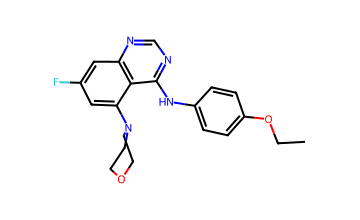


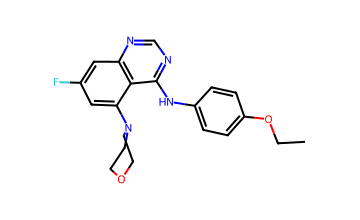
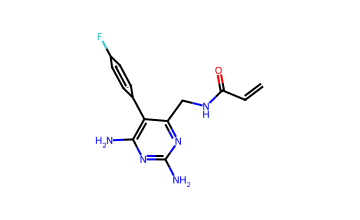
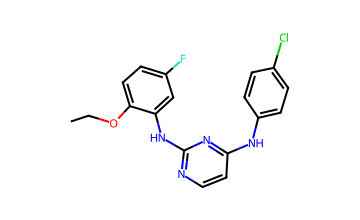
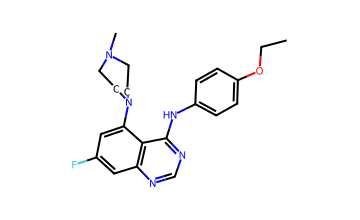

[2026-04-05 12:59:27.218] INFO     (academy.exchange.client) Stop listening on mailbox UserId<f67c333d>
[2026-04-05 12:59:27.250] INFO     (academy.exchange.client) Terminated mailbox for UserId<f67c333d>
[2026-04-05 12:59:27.262] INFO     (academy.exchange.client) Closed exchange client for UserId<f67c333d>
[2026-04-05 12:59:27.263] INFO     (academy.manager) Closed manager (UserId<f67c333d>)


In [8]:
# We will use the Polaris Globus Compute Endpoint for launching the two agents
EP_ID = '9a947ba5-f537-4681-acf3-cc66485aadec'
UEP_CONFIG = {'account': "AuroraGPT", 'queue': 'debug', 
              # Polaris MEP is not set to user `worker_init`, but oddly `config_key` to set env
              'config_key': 'source /home/yadunand/setup_openmm.sh; which python3'}



async def drug_finder():
    
    init_logging()
    
    with GlobusComputeExecutor(endpoint_id=EP_ID, 
                               user_endpoint_config=UEP_CONFIG,
                              ) as remote_exec:
        # Create manager with agents and their assigned executors
        async with await Manager.from_exchange_factory(
            factory=HttpExchangeFactory(),
            executors=remote_exec,
        ) as manager:
            
            # Launch the DrugReasoner and DrugValidator agents on Polaris
            drug_reasoner = await manager.launch(DrugReasoner, args=(api_key,))
            drug_validator = await manager.launch(DrugValidator)

            candidates = await drug_reasoner.generate_candidates("kinase inhibitor targeting EGFR for NSCLC")
            print("Candidates Identified ===================")
            for c in candidates:
                print(f"{c['name']}: {c['smiles']}")
            print("=========================================")

            print("Validating candidates .... ")                
            validated_candidates = await drug_validator.validate_and_featurize(candidates)
            
            print("Estimating binding energies ...")
            
            simulated_candidates = await drug_validator.estimate_binding_energy(validated_candidates)
            
            print(simulated_candidates[0])
            print("Identifying lead candidate ...")
            lead_candidate = await drug_reasoner.select_lead(simulated_candidates)
            
            test(simulated_candidates)
            visualize_results(simulated_candidates, lead_candidate)
        remote_exec.shutdown(wait=True)

await drug_finder()